In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.transforms as transforms
import os
os.chdir("../output/supervised/")

In [2]:
# Load high-dimensional clustering results.
mimic_16 = pd.read_csv("MIMIC_regression_results_16.csv")
mimic_16["dim"] = 16
mimic_32 = pd.read_csv("MIMIC_regression_results_32.csv")
mimic_32["dim"] = 32
mimic_64 = pd.read_csv("MIMIC_regression_results_64.csv")
mimic_64["dim"] = 64
mimic_all = pd.concat([mimic_16, mimic_32, mimic_64], ignore_index=True)
mimic_all = mimic_all[mimic_all["Method"] != "Random"]
# 2 targets: {'Aplasia', 'Neutropenic Fever'}

hancock_16 = pd.read_csv("HANCOCK_regression_results_16.csv")
hancock_16["dim"] = 16
hancock_32 = pd.read_csv("HANCOCK_regression_results_32.csv")
hancock_32["dim"] = 32
hancock_64 = pd.read_csv("HANCOCK_regression_results_64.csv")
hancock_64["dim"] = 64
hancock_all = pd.concat([hancock_16, hancock_32, hancock_64], ignore_index=True)
hancock_all = hancock_all[hancock_all["Method"] != "Random"]
# 4 targets: {'Days to RFS', 'RFS Event', 'Recurrence', 'Survival'}

tcga_16 = pd.read_csv("TCGA_LUAD_regression_results_16.csv")
tcga_16["dim"] = 16
tcga_32 = pd.read_csv("TCGA_LUAD_regression_results_32.csv")
tcga_32["dim"] = 32
tcga_64 = pd.read_csv("TCGA_LUAD_regression_results_64.csv")
tcga_64["dim"] = 64
tcga_all = pd.concat([tcga_16, tcga_32, tcga_64], ignore_index=True)
# 6 targets : {'Disease Free (Months)',
#'Disease Free Status',
#'Disease-specific Survival status',
#'Months of disease-specific survival',
#'Progress Free Survival (Months)',
#'Progression Free Status'}


In [3]:
cat_targets = ["Aplasia", "Disease Free Status", "Disease-specific Survival status", "Neutropenic Fever", "Progression Free Status", "RFS Event", "Recurrence", "Survival"]
hancock_all["Dataset"] = "HANCOCK"
tcga_all["Dataset"] = "TCGA-LUAD"
mimic_all["Dataset"] = "MIMIC"
joint_all = pd.concat([hancock_all, tcga_all, mimic_all], ignore_index=True)
joint_all = joint_all[joint_all["Method"]!="Naive"]
# Compute median per target, method and dimension.
median_scores = joint_all.groupby(["Method", "Target", "dim"])["Score"].median().reset_index()
median_scores = median_scores[median_scores["Target"].isin(cat_targets)].copy()
# Compute best median per target var.
max_scores = median_scores.groupby(["Method", "Target"])["Score"].max().reset_index()
# Count how often each method is best.
pivot = max_scores.pivot(index="Target", columns="Method", values="Score")
agg_df = pd.DataFrame({
    "Method": ["POME", "UMAP"],
    "count": [
        (pivot["POME"] > pivot["UMAP"]).sum(),
        (pivot["UMAP"] > pivot["POME"]).sum()
    ]
})
agg_df

,Method,count
0,POME,7
1,UMAP,1


/tmp/ipykernel_299431/2023576091.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_df, x="Method", y="count", ax=axes['a'],
/tmp/ipykernel_299431/2023576091.py:16: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(data=agg_df, x="Method", y="count", ax=axes['a'],
/tmp/ipykernel_299431/2023576091.py:32: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(data=aplasia_all, x="dim", y="Score",
/tmp/ipykernel_299431/2023576091.py:71: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(data=nf_all, x="dim", y="Score",
/tmp/ipykernel_299431/2023576091.py:96: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(

Text(0.0, 1.0, 'i')

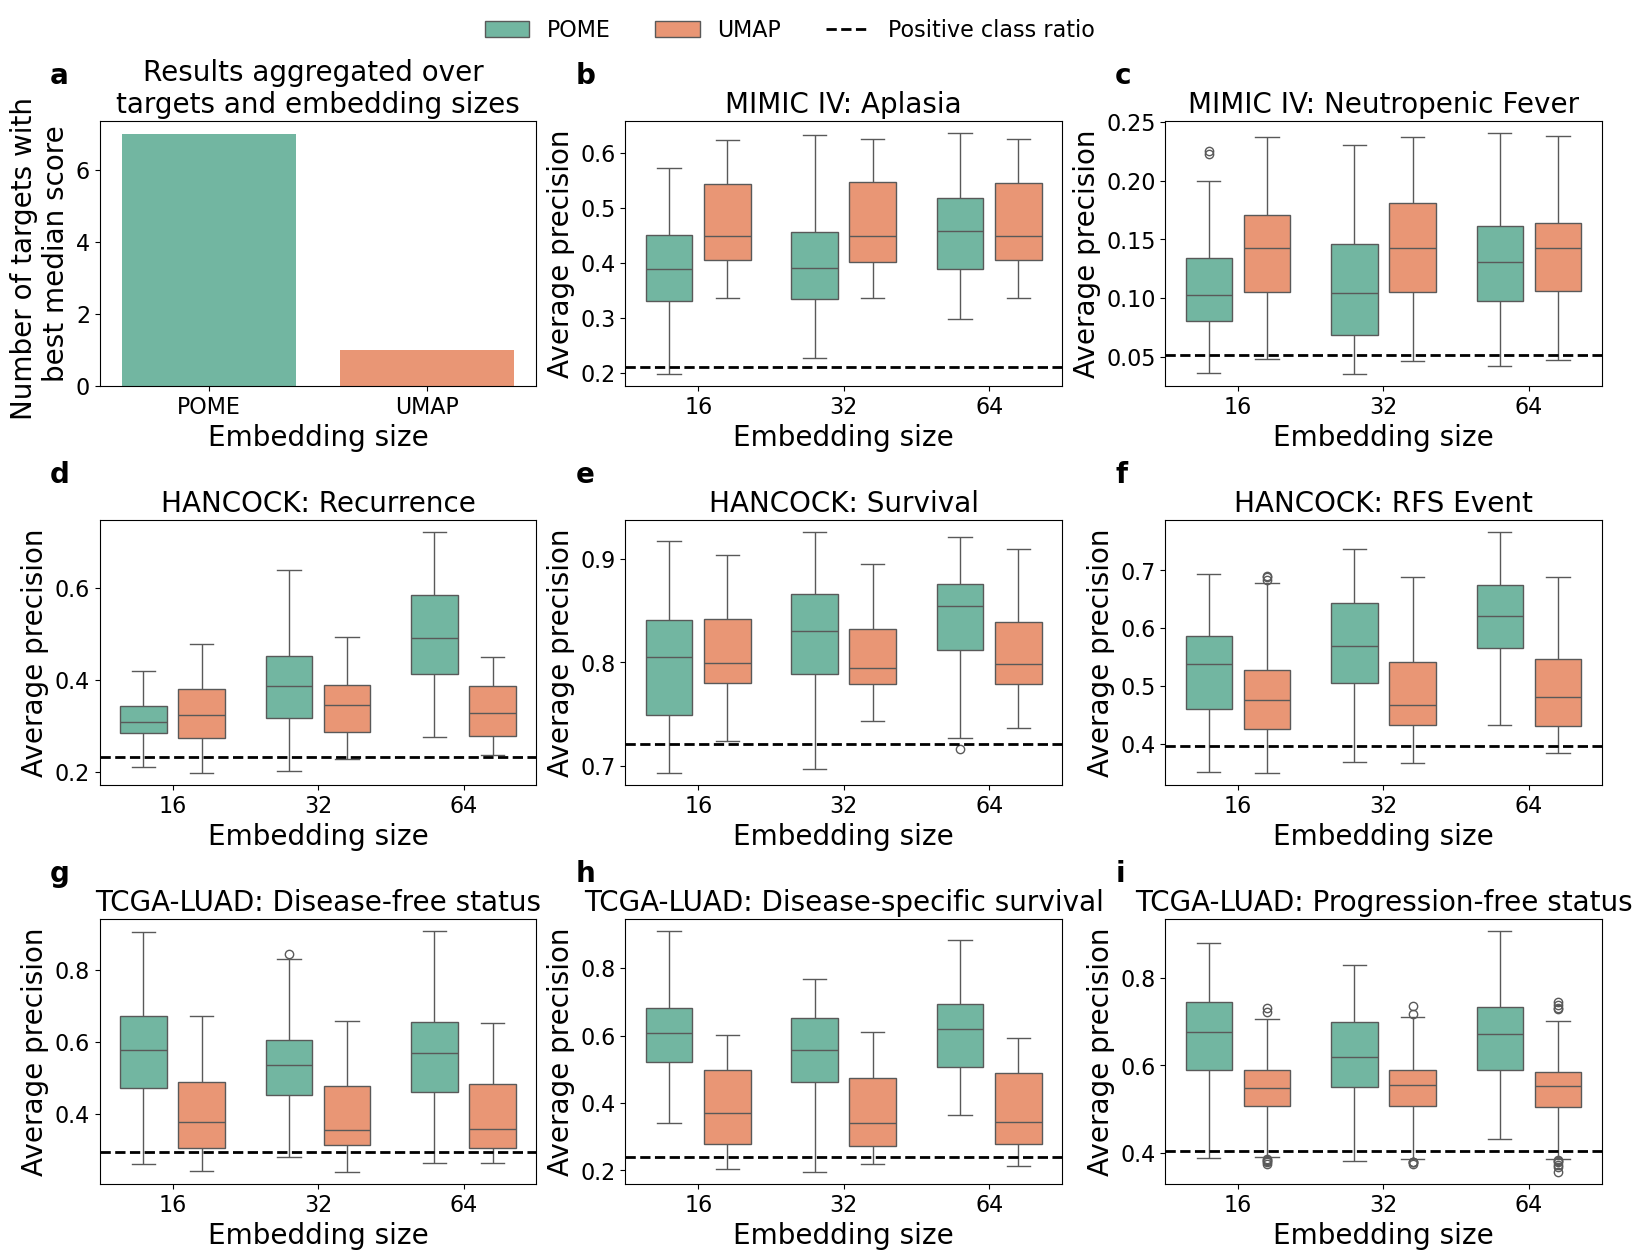

In [4]:
mosaic = [
['a', 'b', 'c'], ['d', 'e', 'f'], ['g', 'h', 'i']
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(16,12), layout='constrained')

offset = transforms.ScaledTranslation(-36/72, 27/72, fig.dpi_scale_trans)
labelfontsize = 20
titlefontsize = 20
ticklabelsize = 16
xylabelsize = 18
legendfontsize = 16
legendtitlefontsize = 18
pvalfontsize = 18

# Aggregated plot first.
sns.barplot(data=agg_df, x="Method", y="count", ax=axes['a'],
             palette=sns.color_palette("Set2"))
axes['a'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['a'].set_ylabel('Number of targets with \nbest median score', fontsize=labelfontsize) 
axes['a'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['a'].tick_params(axis='y', labelsize=ticklabelsize) 
#axes['b'].set_yticks([0.0, 1.0, 2.0])
#axes['a'].set_ylim(0.1, 0.65)
axes['a'].set_title("Results aggregated over \ntargets and embedding sizes", fontsize=titlefontsize)
axes['a'].text(0.0, 1.0, 'a', transform=axes['a'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
aplasia_all = mimic_all[mimic_all["Target"] == "Aplasia"]
aplasia_naive = aplasia_all.loc[aplasia_all["Method"] == "Naive", "Score"].iloc[0]
aplasia_all = aplasia_all[aplasia_all["Method"]!= "Naive"]

sns.boxplot(data=aplasia_all, x="dim", y="Score",
             hue="Method", ax=axes['b'], dodge=True, gap=.2,
             legend=True, palette=sns.color_palette("Set2"))

# Horizontal dashed line for Naive
axes['b'].axhline(
    aplasia_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['b'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['b'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['b'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['b'].tick_params(axis='y', labelsize=ticklabelsize) 
#axes['b'].set_yticks([0.0, 1.0, 2.0])
#axes['a'].set_ylim(0.1, 0.65)
axes['b'].set_title("MIMIC IV: Aplasia", fontsize=titlefontsize)
axes['b'].text(0.0, 1.0, 'b', transform=axes['b'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

handles, labels = axes["b"].get_legend_handles_labels()
axes["b"].legend_.remove()

legend1 = fig.legend(
    handles, labels,
    loc="center",
    bbox_to_anchor=(0.49, 1.02),   # adjust this value
    ncol=len(labels),
    fontsize=legendfontsize,
    frameon=False
)

# Subset data
nf_all = mimic_all[mimic_all["Target"] == "Neutropenic Fever"]
nf_naive = nf_all.loc[nf_all["Method"] == "Naive", "Score"].iloc[0]
nf_all = nf_all[nf_all["Method"]!= "Naive"]

sns.boxplot(data=nf_all, x="dim", y="Score",
             hue="Method", ax=axes['c'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))

# Horizontal dashed line for Naive
axes['c'].axhline(
    nf_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['c'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['c'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['c'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['c'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['c'].set_title("MIMIC IV: Neutropenic Fever", fontsize=titlefontsize)
axes['c'].text(0.0, 1.0, 'c', transform=axes['c'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')


# Subset data
rec_all = hancock_all[hancock_all["Target"] == "Recurrence"]
rec_naive = rec_all.loc[rec_all["Method"] == "Naive", "Score"].iloc[0]
rec_all = rec_all[rec_all["Method"]!= "Naive"]
sns.boxplot(data=rec_all, x="dim", y="Score",
             hue="Method", ax=axes['d'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))

# Horizontal dashed line for Naive
axes['d'].axhline(
    rec_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['d'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['d'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['d'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['d'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['d'].set_title("HANCOCK: Recurrence", fontsize=titlefontsize)
axes['d'].text(0.0, 1.0, 'd', transform=axes['d'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
surv_all = hancock_all[hancock_all["Target"] == "Survival"]
surv_naive = surv_all.loc[surv_all["Method"] == "Naive", "Score"].iloc[0]
surv_all = surv_all[surv_all["Method"]!= "Naive"]
sns.boxplot(data=surv_all, x="dim", y="Score",
             hue="Method", ax=axes['e'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))

# Horizontal dashed line for Naive
axes['e'].axhline(
    surv_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['e'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['e'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['e'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['e'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['e'].set_title("HANCOCK: Survival", fontsize=titlefontsize)
axes['e'].text(0.0, 1.0, 'e', transform=axes['e'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
rfs_all = hancock_all[hancock_all["Target"] == "RFS Event"]
rfs_naive = rfs_all.loc[rfs_all["Method"] == "Naive", "Score"].iloc[0]
rfs_all = rfs_all[rfs_all["Method"]!= "Naive"]
sns.boxplot(data=rfs_all, x="dim", y="Score",
             hue="Method", ax=axes['f'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))

# Horizontal dashed line for Naive
axes['f'].axhline(
    rfs_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['f'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['f'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['f'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['f'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['f'].set_title("HANCOCK: RFS Event", fontsize=titlefontsize)
axes['f'].text(0.0, 1.0, 'f', transform=axes['f'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
dfs_all = tcga_all[tcga_all["Target"] == "Disease Free Status"]
dfs_naive = dfs_all.loc[dfs_all["Method"] == "Naive", "Score"].iloc[0]
dfs_all = dfs_all[dfs_all["Method"]!= "Naive"]
sns.boxplot(data=dfs_all, x="dim", y="Score",
             hue="Method", ax=axes['g'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))

# Horizontal dashed line for Naive
axes['g'].axhline(
    dfs_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['g'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['g'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['g'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['g'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['g'].set_title("TCGA-LUAD: Disease-free status", fontsize=titlefontsize)
axes['g'].text(0.0, 1.0, 'g', transform=axes['g'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
dss_all = tcga_all[tcga_all["Target"] == "Disease-specific Survival status"]
dss_naive = dss_all.loc[dss_all["Method"] == "Naive", "Score"].iloc[0]
dss_all = dss_all[dss_all["Method"]!= "Naive"]
sns.boxplot(data=dss_all, x="dim", y="Score",
             hue="Method", ax=axes['h'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))

# Horizontal dashed line for Naive
axes['h'].axhline(
    dss_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['h'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['h'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['h'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['h'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['h'].set_title("TCGA-LUAD: Disease-specific survival", fontsize=titlefontsize)
axes['h'].text(0.0, 1.0, 'h', transform=axes['h'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
pfs_all = tcga_all[tcga_all["Target"] == "Progression Free Status"]
pfs_naive = pfs_all.loc[pfs_all["Method"] == "Naive", "Score"].iloc[0]
pfs_all = pfs_all[pfs_all["Method"]!= "Naive"]
sns.boxplot(data=pfs_all, x="dim", y="Score",
             hue="Method", ax=axes['i'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))

# Horizontal dashed line for Naive
axes['i'].axhline(
    pfs_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['i'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['i'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['i'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['i'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['i'].set_title("TCGA-LUAD: Progression-free status", fontsize=titlefontsize)
axes['i'].text(0.0, 1.0, 'i', transform=axes['i'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

#plt.savefig("supervised_learning_results.pdf", bbox_inches='tight', bbox_extra_artists=[legend1])